In [ ]:
#VIDHYASHREE G S -AMB2292

In [ ]:
import tensorflow as tf
#step 1: load dataset
mnist=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("train images shape:",train_images.shape)  #(60000,28,28)
print("train labels shape:",train_labels.shape)
print("test images shape:",test_images.shape)
print("test labels shape:",test_labels.shape)

train images shape: (60000, 28, 28)
train labels shape: (60000,)
test images shape: (10000, 28, 28)
test labels shape: (10000,)


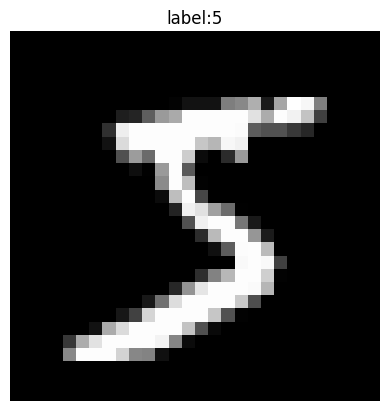

In [ ]:
import matplotlib.pyplot as plt
#plot first image
plt.imshow(train_images[0],cmap="gray")
plt.title(f"label:{train_labels[0]}") #show the labels
plt.axis('off')
plt.show()

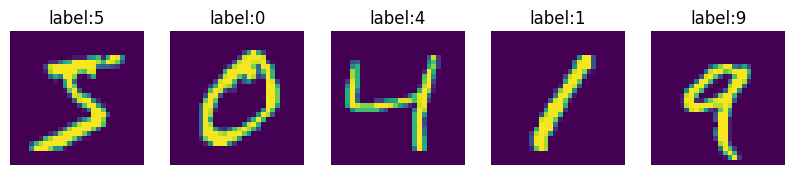

In [ ]:
#first 5 images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_images[i],)
    plt.title(f"label:{train_labels[i]}")
    plt.axis("off")
plt.show()

In [ ]:
#step2:normalize values(0 to 1)
train_images=train_images/255.0
test_images=test_images/225.0

In [ ]:
#step 3:add channel dimension (import for CNN)
train_images= train_images.reshape((60000,28,28,1))
test_iamges=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import models,layers,Input

model=models.Sequential([
    Input(shape=(28,28,1)),
    layers.Conv2D(16,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [ ]:
#step:5 compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#step6:tain model
model.fit(train_images,train_labels,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.1122 - loss: 2.3015
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.1124 - loss: 2.3014
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.1124 - loss: 2.3014


In [ ]:
test_loss,test_accuracy=model.evaluate(test_images,test_labels)
print(f"Test accuracy:{test_accuracy}")
print(f"Test loss:{test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1135 - loss: 2.3010
Test accuracy:0.11349999904632568
Test loss:2.301024913787842


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Original Label: 7
Predicted Label: 1


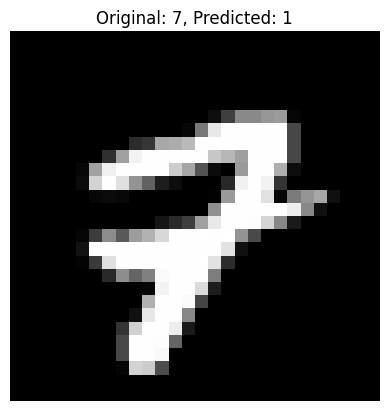

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf

# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)), # Added Input layer here
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.1117 - loss: 2.3016
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.1124 - loss: 2.3014
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1135 - loss: 2.3012
Accuracy: 0.11349999904632568
